# Simple neural network 

### Tensorflow implementation

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
X,y=make_classification(n_samples=500,n_features=2,n_redundant=0,n_informative=2,random_state=42)

In [3]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
X_scaled=scaler.fit_transform(X)

In [4]:
model=tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(2,)),
    tf.keras.layers.Dense(1, activation='softmax')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
fitting=model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test)) 

c:\Users\ddali\AI\Deep learning\dl\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


c:\Users\ddali\AI\Deep learning\dl\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.5025 - loss: 0.5993 - val_accuracy: 0.5000 - val_loss: 0.6290
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5025 - loss: 0.5732 - val_accuracy: 0.5000 - val_loss: 0.6027
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5025 - loss: 0.5496 - val_accuracy: 0.5000 - val_loss: 0.5790
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5025 - loss: 0.5282 - val_accuracy: 0.5000 - val_loss: 0.5570
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5025 - loss: 0.5083 - val_accuracy: 0.5000 - val_loss: 0.5369
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5025 - loss: 0.4900 - val_accuracy: 0.5000 - val_loss: 0.5189
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5025 - loss: 0.4727 - val_accuracy: 0.5000 - val_loss: 0.5014
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5025 - loss: 0.4573 - val_accuracy: 0.5000 - val_loss: 0.48

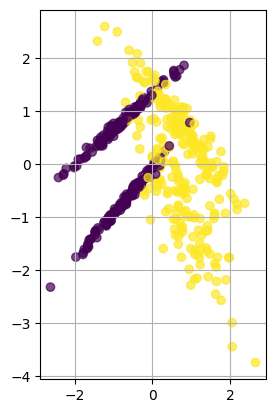

In [9]:
import matplotlib.pyplot as plt
plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1],c=y,cmap='viridis',alpha=0.7)
plt.grid(True)
plt.show()

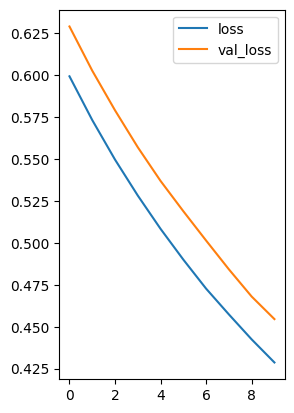

In [10]:
plt.subplot(1,2,2)
plt.plot(fitting.history['loss'],label='loss')
plt.plot(fitting.history['val_loss'],label='val_loss')
plt.legend()
plt.show()

### Pytorch implementation

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import accuracy_score

In [12]:
X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)

In [13]:
class SimpleNN(nn.Module):
    def __init__(self,input_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim,10)
        self.fc2 = nn.Linear(10,1)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

In [15]:
model=SimpleNN(input_dim=2)
criterion=nn.BCELoss()
optimizer=optim.Adam(model.parameters(),lr=0.01)

In [16]:
num_epochs = 30
train_accuracies = []
test_accuracies = []
losses = []

for epoch in range(num_epochs):
    model.train()

    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        # Training accuracy
        train_preds = (outputs >= 0.5).float()
        train_acc = accuracy_score(y_train_tensor.numpy(), train_preds.numpy())

        # Test accuracy
        test_outputs = model(X_test_tensor)
        test_preds = (test_outputs >= 0.5).float()
        test_acc = accuracy_score(y_test_tensor.numpy(), test_preds.numpy())

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    losses.append(loss.item())

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {loss.item():.4f} - Train Acc: {train_acc:.4f} - Test Acc: {test_acc:.4f}")

Epoch 1/30 - Loss: 0.8530 - Train Acc: 0.4975 - Test Acc: 0.5000
Epoch 2/30 - Loss: 0.8325 - Train Acc: 0.4975 - Test Acc: 0.5000
Epoch 3/30 - Loss: 0.8132 - Train Acc: 0.4975 - Test Acc: 0.5000
Epoch 4/30 - Loss: 0.7950 - Train Acc: 0.4975 - Test Acc: 0.5000
Epoch 5/30 - Loss: 0.7780 - Train Acc: 0.4975 - Test Acc: 0.5000
Epoch 6/30 - Loss: 0.7620 - Train Acc: 0.4975 - Test Acc: 0.5000
Epoch 7/30 - Loss: 0.7468 - Train Acc: 0.4975 - Test Acc: 0.5000
Epoch 8/30 - Loss: 0.7325 - Train Acc: 0.4975 - Test Acc: 0.5000
Epoch 9/30 - Loss: 0.7189 - Train Acc: 0.4975 - Test Acc: 0.5000
Epoch 10/30 - Loss: 0.7059 - Train Acc: 0.4975 - Test Acc: 0.5000
Epoch 11/30 - Loss: 0.6936 - Train Acc: 0.4975 - Test Acc: 0.5000
Epoch 12/30 - Loss: 0.6819 - Train Acc: 0.4975 - Test Acc: 0.5000
Epoch 13/30 - Loss: 0.6707 - Train Acc: 0.4975 - Test Acc: 0.5000
Epoch 14/30 - Loss: 0.6601 - Train Acc: 0.4975 - Test Acc: 0.5000
Epoch 15/30 - Loss: 0.6500 - Train Acc: 0.4975 - Test Acc: 0.5000
Epoch 16/30 - Loss:

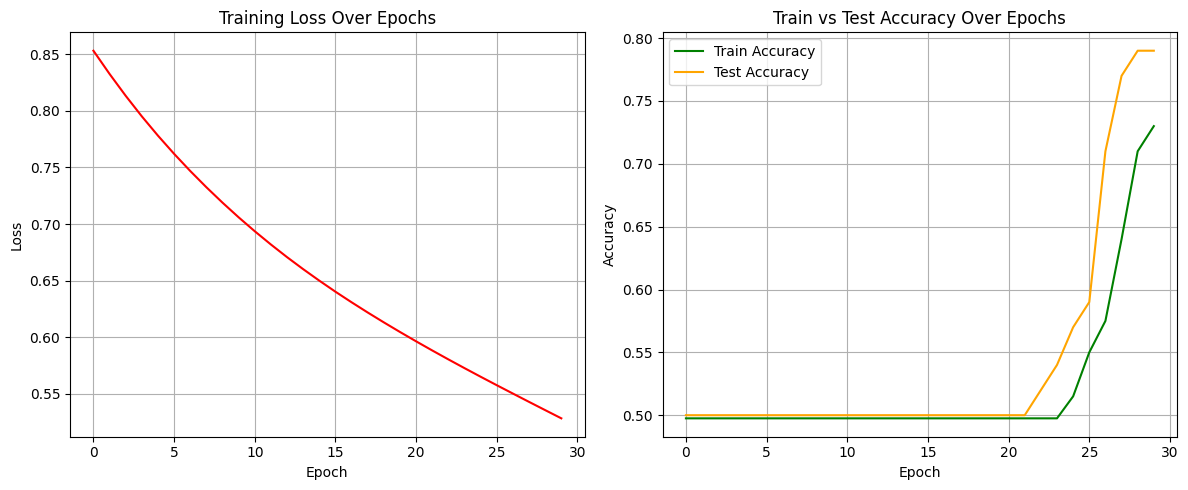

In [17]:
plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(losses, label="Loss", color='red')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

# Combined Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy", color='green')
plt.plot(test_accuracies, label="Test Accuracy", color='orange')
plt.title("Train vs Test Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()